# When Does a Word Become a Concept?
## Diachronic embeddings of *culture* in nineteenth-century British newspapers

This notebook contains the calculations and visualisations used in the article  
**«Когда слово становится понятием? Диахронические векторные модели в исследовании культуры (на материале британской прессы XIX века)»**.

The analysis uses the published decade-level word embeddings from the *Living with Machines* project (1800s–1910s):  
Zenodo record **7181682**.

Methodological reference:  
Pedrazzini N., McGillivray B. *Machines in the Media: Semantic Change in the Lexicon of Mechanization in 19th-Century British Newspapers*. NLP4DH, 2022. DOI: 10.18653/v1/2022.nlp4dh-1.12.

## Setup

In [1]:
!pip -q install "gensim>=4.3,<5" "ruptures>=1.1,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm.auto import tqdm

import scipy.linalg
if not hasattr(scipy.linalg, "triu"):
    scipy.linalg.triu = np.triu

from gensim.models import KeyedVectors
import ruptures as rpt
from IPython.display import display

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## Data and parameters

In [3]:
PERIODS = [
    "1800s", "1810s", "1820s", "1830s", "1840s", "1850s",
    "1860s", "1870s", "1880s", "1890s", "1900s", "1910s"
]
REFERENCE = "1910s"
EARLIER = PERIODS[:-1]

ZENODO_RECORD = 7181682
MODEL_DIR = Path("/content/lwm_vectors")
MODEL_DIR.mkdir(exist_ok=True)

AGRICULTURAL_FIELD = [
    "soil", "agriculture", "agricultural",
    "land", "farming", "crop", "husbandry"
]

INTELLECTUAL_FIELD = [
    "education", "learning", "knowledge",
    "literature", "art", "science", "taste"
]

CONTROL_WORDS = [
    "mother", "father", "horse", "bread", "water", "church",
    "winter", "morning", "village", "garden", "friend", "dinner"
]

CULTURE_DECADES = ["1800s", "1840s", "1850s", "1860s", "1870s"]
CIVILISATION_DECADES = ["1820s", "1840s", "1860s", "1880s", "1910s"]

TOPN = 30

In [4]:
def download_model(period):
    path = MODEL_DIR / f"{period}-vectors.txt"
    if path.exists():
        return path

    url = (
        f"https://zenodo.org/records/{ZENODO_RECORD}/files/"
        f"{period}-vectors.txt?download=1"
    )

    with requests.get(url, stream=True, timeout=(30, 600)) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))

        with path.open("wb") as f, tqdm(
            total=total if total else None,
            unit="B",
            unit_scale=True,
            desc=period
        ) as bar:
            for chunk in response.iter_content(chunk_size=4 << 20):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

    return path

model_paths = {period: download_model(period) for period in PERIODS}

1800s: 0.00B [00:00, ?B/s]

1810s: 0.00B [00:00, ?B/s]

1820s: 0.00B [00:00, ?B/s]

1830s: 0.00B [00:00, ?B/s]

1840s: 0.00B [00:00, ?B/s]

...

1870s: 0.00B [00:00, ?B/s]

1880s: 0.00B [00:00, ?B/s]

1890s: 0.00B [00:00, ?B/s]

1900s: 0.00B [00:00, ?B/s]

1910s: 0.00B [00:00, ?B/s]

## Analysis

In [5]:
def load_model(period):
    model = KeyedVectors.load_word2vec_format(
        str(model_paths[period]),
        binary=False,
        unicode_errors="ignore"
    )
    model.fill_norms(force=True)
    return model

def vector(model, word):
    if word not in model:
        return None
    return model.get_vector(word, norm=True)

def cosine(v1, v2):
    if v1 is None or v2 is None:
        return np.nan
    return float(np.dot(v1, v2))

def mean_similarity(model, target, words):
    target_vector = vector(model, target)
    similarities = [
        cosine(target_vector, vector(model, word))
        for word in words
        if word in model
    ]
    return float(np.mean(similarities))

def neighbors(model, word, topn=TOPN):
    return model.most_similar(word, topn=topn)

def neighbor_table(df, decades):
    selected = df[df["decade"].isin(decades)].copy()
    selected["item"] = (
        selected["neighbor"]
        + " ("
        + selected["similarity"].map(lambda x: f"{x:.3f}")
        + ")"
    )
    return (
        selected.pivot(index="rank", columns="decade", values="item")
        .reindex(columns=decades)
    )

In [6]:
reference_model = load_model(REFERENCE)
reference_words = ["culture"] + CONTROL_WORDS
reference_vectors = {
    word: vector(reference_model, word)
    for word in reference_words
}
del reference_model
gc.collect()

shift_rows = []
field_rows = []
relation_rows = []
culture_neighbor_rows = []
civilisation_neighbor_rows = []

for period in tqdm(PERIODS, desc="Decades"):
    model = load_model(period)

    if period in EARLIER:
        for word in reference_words:
            shift_rows.append({
                "decade": period,
                "word": word,
                "cosine_to_1910s": cosine(
                    vector(model, word),
                    reference_vectors[word]
                )
            })

    field_rows.append({
        "decade": period,
        "agricultural_cultivation": mean_similarity(
            model, "culture", AGRICULTURAL_FIELD
        ),
        "education_intellectual_life": mean_similarity(
            model, "culture", INTELLECTUAL_FIELD
        )
    })

    culture_vector = vector(model, "culture")
    relation_rows.append({
        "decade": period,
        "culture_cultivation": cosine(
            culture_vector, vector(model, "cultivation")
        ),
        "culture_civilisation": cosine(
            culture_vector, vector(model, "civilisation")
        )
    })

    for rank, (word, similarity) in enumerate(
        neighbors(model, "culture"), start=1
    ):
        culture_neighbor_rows.append({
            "decade": period,
            "rank": rank,
            "neighbor": word,
            "similarity": similarity
        })

    for rank, (word, similarity) in enumerate(
        neighbors(model, "civilisation"), start=1
    ):
        civilisation_neighbor_rows.append({
            "decade": period,
            "rank": rank,
            "neighbor": word,
            "similarity": similarity
        })

    del model
    gc.collect()

shift_df = pd.DataFrame(shift_rows)
fields_df = pd.DataFrame(field_rows).set_index("decade")
relations_df = pd.DataFrame(relation_rows).set_index("decade")
culture_neighbors_df = pd.DataFrame(culture_neighbor_rows)
civilisation_neighbors_df = pd.DataFrame(civilisation_neighbor_rows)

Decades:   0%|          | 0/12 [00:00<?, ?it/s]

## Temporal trajectory

,culture → 1910s,control mean
decade,,
1800s,0.617,0.709
1810s,0.694,0.734
1820s,0.655,0.761
1830s,0.571,0.680
1840s,0.698,0.769
1850s,0.791,0.792
1860s,0.756,0.779
1870s,0.783,0.841
1880s,0.794,0.852


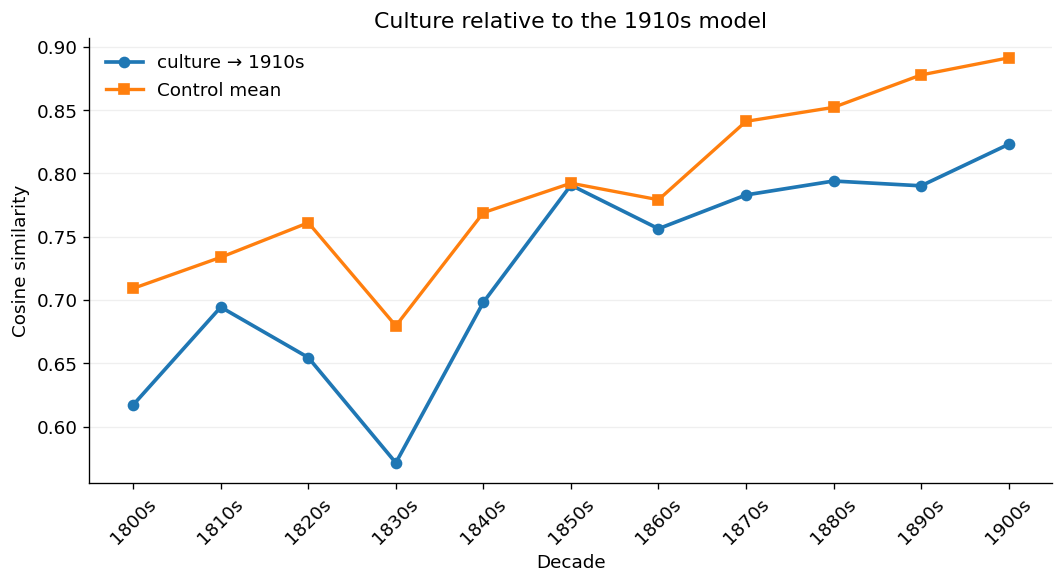

In [7]:
shift_pivot = shift_df.pivot(
    index="decade",
    columns="word",
    values="cosine_to_1910s"
).reindex(EARLIER)

culture_shift = shift_pivot["culture"]
control_mean = shift_pivot[CONTROL_WORDS].mean(axis=1)

display(pd.DataFrame({
    "culture → 1910s": culture_shift,
    "control mean": control_mean
}).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(EARLIER, culture_shift, marker="o", linewidth=2.2, label="culture → 1910s")
ax.plot(EARLIER, control_mean, marker="s", linewidth=2.0, label="Control mean")
ax.set_xlabel("Decade")
ax.set_ylabel("Cosine similarity")
ax.set_title("Culture relative to the 1910s model")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [8]:
values = culture_shift.to_numpy()

for penalty in [0.25, 0.50]:
    changepoints = rpt.Pelt(
        model="l1",
        jump=1,
        min_size=2
    ).fit(values).predict(pen=penalty)

    internal = [point for point in changepoints if point < len(values)]

    if internal:
        transitions = [
            f"{EARLIER[point - 1]} → {EARLIER[point]}"
            for point in internal
        ]
        print(f"PELT, penalty={penalty}: {', '.join(transitions)}")
    else:
        print(f"PELT, penalty={penalty}: no internal changepoint")

PELT, penalty=0.25: 1840s → 1850s
PELT, penalty=0.5: no internal changepoint


## Nearest neighbours of *culture*

In [9]:
display(neighbor_table(culture_neighbors_df, CULTURE_DECADES))

decade,1800s,1840s,1850s,1860s,1870s
rank,,,,,
1,parsnips (0.733),cultivation (0.886),cultivation (0.893),cultivation (0.865),cultivation (0.786)
2,cultivation (0.731),cultivating (0.733),cultivated (0.793),cultivated (0.788),intellectual (0.744)
3,harvesting (0.729),cultivated (0.730),cultivating (0.769),cultivating (0.767),cultivated (0.740)
4,tillage (0.724),tillage (0.704),germination (0.759),intellectual (0.751),cultivating (0.722)
5,cucumber (0.721),husbandry (0.695),cultivate (0.747),germination (0.741),cultivates (0.722)
6,boggy (0.713),cultivate (0.693),husbandry (0.746),cultivate (0.741),ripeness (0.717)
7,grasses (0.712),planting (0.687),development (0.746),indigenous (0.737),humanizing (0.715)
8,vegetation (0.706),agriculture (0.685),developement (0.743),development (0.736),refinement (0.715)
9,blights (0.705),growth (0.674),grafting (0.739),learning (0.733),fruitfulness (0.713)


## Diagnostic semantic fields

,Agriculture / cultivation,Education / intellectual life
decade,,
1800s,0.577,0.465
1810s,0.609,0.533
1820s,0.587,0.533
1830s,0.470,0.369
1840s,0.618,0.535
1850s,0.646,0.643
1860s,0.595,0.647
1870s,0.542,0.623
1880s,0.556,0.603


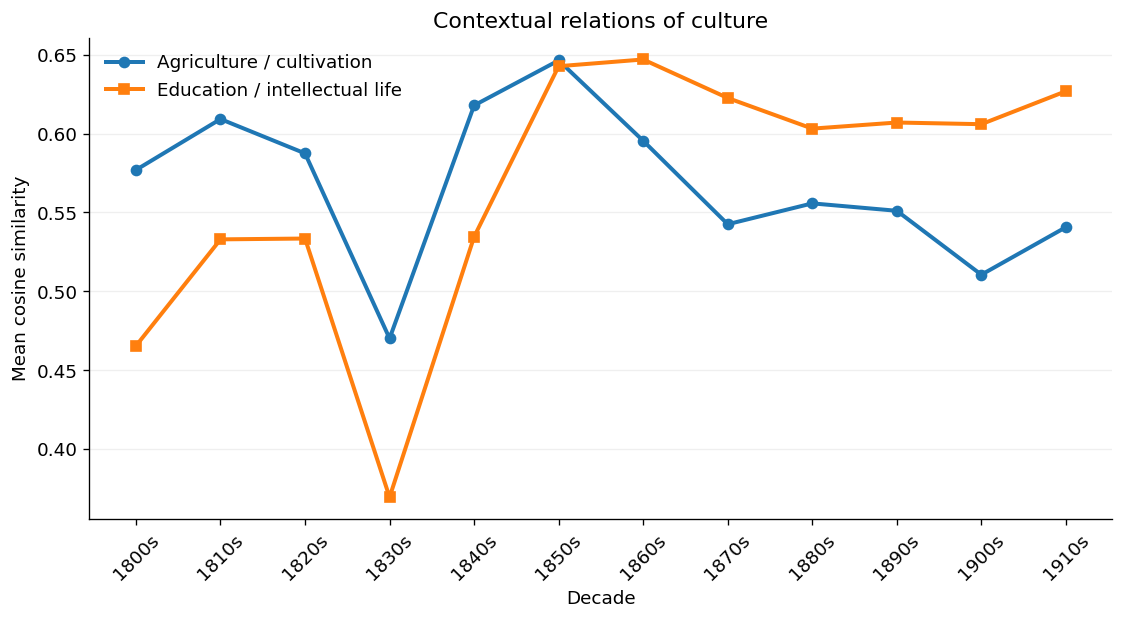

In [10]:
field_table = fields_df.rename(columns={
    "agricultural_cultivation": "Agriculture / cultivation",
    "education_intellectual_life": "Education / intellectual life"
})

display(field_table.round(3))

fig, ax = plt.subplots(figsize=(9.5, 5.3))
ax.plot(
    PERIODS,
    fields_df["agricultural_cultivation"],
    marker="o",
    linewidth=2.4,
    label="Agriculture / cultivation"
)
ax.plot(
    PERIODS,
    fields_df["education_intellectual_life"],
    marker="s",
    linewidth=2.4,
    label="Education / intellectual life"
)
ax.set_xlabel("Decade")
ax.set_ylabel("Mean cosine similarity")
ax.set_title("Contextual relations of culture")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## *Culture*, *cultivation*, and *civilisation*

,culture ↔ cultivation,culture ↔ civilisation
decade,,
1800s,0.731,0.618
1810s,0.752,0.692
1820s,0.827,0.623
1830s,0.777,0.397
1840s,0.886,0.612
1850s,0.893,0.685
1860s,0.865,0.672
1870s,0.786,0.637
1880s,0.780,0.650


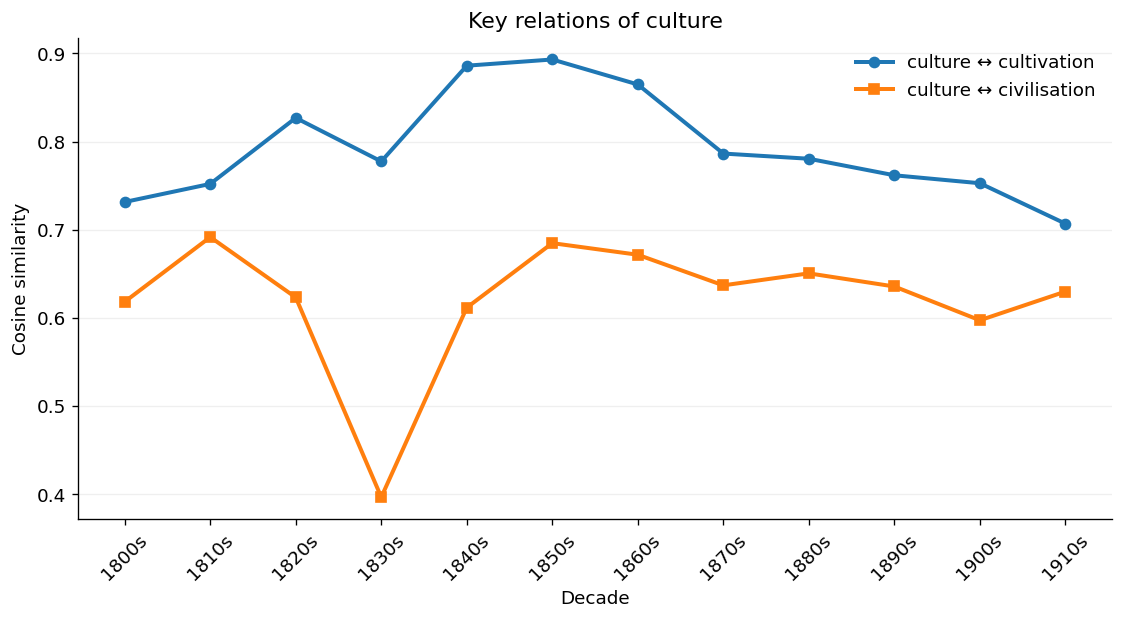

In [11]:
relation_table = relations_df.rename(columns={
    "culture_cultivation": "culture ↔ cultivation",
    "culture_civilisation": "culture ↔ civilisation"
})

display(relation_table.round(3))

fig, ax = plt.subplots(figsize=(9.5, 5.3))
ax.plot(
    PERIODS,
    relations_df["culture_cultivation"],
    marker="o",
    linewidth=2.4,
    label="culture ↔ cultivation"
)
ax.plot(
    PERIODS,
    relations_df["culture_civilisation"],
    marker="s",
    linewidth=2.4,
    label="culture ↔ civilisation"
)
ax.set_xlabel("Decade")
ax.set_ylabel("Cosine similarity")
ax.set_title("Key relations of culture")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Nearest neighbours of *civilisation*

In [12]:
display(neighbor_table(civilisation_neighbors_df, CIVILISATION_DECADES))

decade,1820s,1840s,1860s,1880s,1910s
rank,,,,,
1,civilization (0.901),civilization (0.943),civilization (0.947),civilization (0.930),civilization (0.856)
2,civilize (0.806),christianity (0.791),christianity (0.808),civilizing (0.810),paganism (0.817)
3,feudalism (0.799),barbarism (0.777),barbarism (0.802),christianity (0.798),barbarism (0.814)
4,civilising (0.797),morality (0.754),civilizing (0.797),barbarism (0.793),christianity (0.810)
5,prospering (0.791),humanity (0.744),humanity (0.781),civilising (0.780),commercialism (0.804)
6,civilise (0.789),democracies (0.742),greatness (0.769),humanities (0.770),dynasties (0.792)
7,preeminence (0.788),democracy (0.735),civilize (0.757),paganism (0.769),humanity (0.792)
8,civilizing (0.787),civilising (0.733),mankind (0.757),peopling (0.766),serfdom (0.792)
9,nascent (0.785),diffusion (0.732),humanizing (0.755),puritanism (0.761),germanic (0.785)
